# Sampling


(225, 225)
uint8


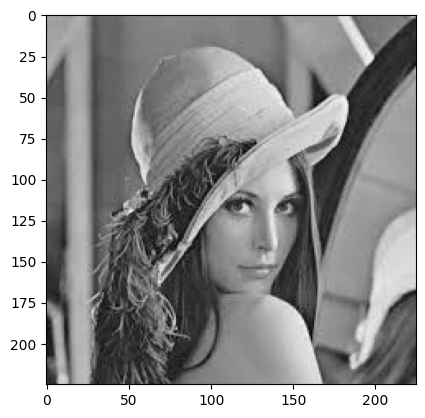

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src = cv2.imread("images/lenna.jpeg", cv2.IMREAD_GRAYSCALE)  # Read as grayscale for simplicity
plt.imshow(src, cmap="gray")
print(src.shape)
print(src.dtype)
plt.show()


다운 샘플링

(64, 64)


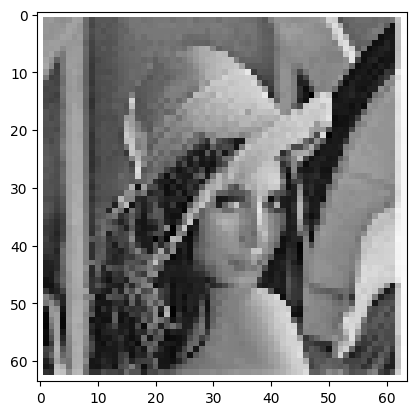

In [ ]:
h, w = src.shape # hxwxc
h_new, w_new = 64, 64

idx_h = np.linspace(0, h-1, h_new).astype(int) #linspace 는 등간격으로 만들어주는 함수, 0~h-1 사이를 h_new 개로 나눠서 만들어줌
#반드시 int 로 바꿔줘야함, linspace 는 float 형태로 나옴
idx_w = np.linspace(0, w-1, w_new).astype(int)


#****You should not do this!!!****
#dst = src[idx_h, idx_w] # Wrong!!!
dst = src[idx_h][:,idx_w] # Correct
print(dst.shape)

plt.imshow(dst, cmap="gray")
plt.show()

## Use Open-CV


(730, 746)
(256, 64)


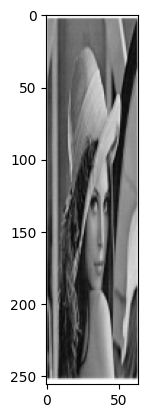

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src = cv2.imread("images/lenna.jpeg", cv2.IMREAD_GRAYSCALE)  # Read as grayscale for simplicity
print(src.shape)

h, w = 256, 64
dst = cv2.resize(src, (w, h), interpolation=cv2.INTER_AREA) ## x-y order
# H x W -> h x w (x-y order), interpolation 은 신경안써도됨
print(dst.shape)
plt.imshow(dst, cmap="gray")

# Quantization

#### $Q=8$ bits
- The number of levels: $L=2^8 = 256$
- $I[i,j] \in \{0, 1, 2, \cdots, 254, 255 \}$
    - $0\le i \le H-1,~0\le j \le W-1$

#### $Q=4$ bits
- The number of levels: $L=2^4 = 16$
- $I[i,j] \in \{0, 1, 2, \cdots, 14, 15 \}$
    - $0\le i \le H-1,~0\le j \le W-1$



#### $Q=2$ bits
- $L$ is reduced from `16` to `4`
- What if $I[i,j] \in \{0, 1, 2, 3\}$ ?
    - Will be very dark.
    - $\min$ and $\max$ should be the same to have the `same brightness`
- `All levels should equally spaced`
- `Pixels` should be `re-mappted` to one in $\color{yellow}\{0, 4, 8, 12 \}$
-  <span style="color:yellow"> Interval is 4 </span>

#### An example for reducing $Q$ from 8 bits to 4 bits

<nop/> <div style="width:1000px">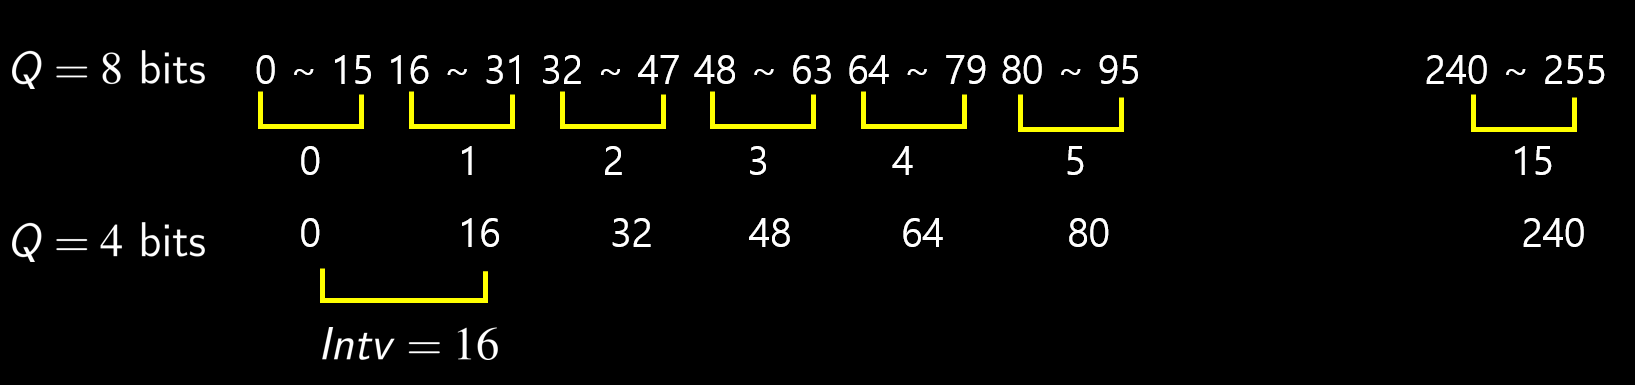


- For $Q=8$ bits $I[i,j]\in \{0, 1, \cdots, 255 \}$ 
    - 256 levels

- For $Q=4$, we have `16 levels`
    - $Intv =256//16 = 16$  
    - $I[i,j]//Intv \in  \{0, 1, \cdots, 15 \}$
    - $(I[i,j]//Intv) \times Intv \in  \{0, 16, 32, \cdots, 224, 240 \}$

In [3]:
import numpy as np
img = np.arange(256)
print(img)


n_bits = 4
n_levels = 2**n_bits
intv = 256 // n_levels
(img // intv) * intv

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,  16,  16,  16,  16,  16,  16,  16,  16,  16,  16,
        16,  16,  16,  16,  16,  16,  32,  32,  32,  32,  32,  32,  32,
        32,  32,  32,  32,  32,  32,  32,  32,  32,  48,  48,  48,  48,
        48,  48,  48,  48,  48,  48,  48,  48,  48,  48,  48,  48,  64,
        64,  64,  64,  64,  64,  64,  64,  64,  64,  64,  64,  64,  64,
        64,  64,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,
        80,  80,  80,  80,  80,  96,  96,  96,  96,  96,  96,  96,  96,
        96,  96,  96,  96,  96,  96,  96,  96, 112, 112, 112, 112, 112,
       112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 128, 128,
       128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128,
       128, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144,
       144, 144, 144, 144, 160, 160, 160, 160, 160, 160, 160, 160, 160,
       160, 160, 160, 160, 160, 160, 160, 176, 176, 176, 176, 17

### Images
- The default number of levels: `n_levels=256`

4 64


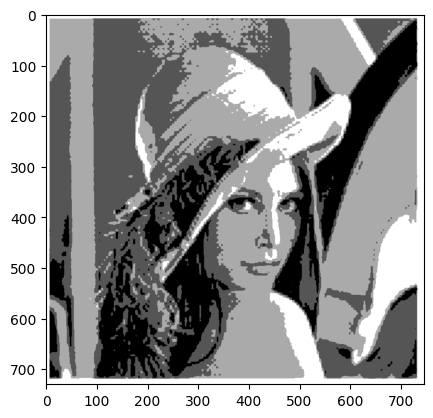

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src = cv2.imread("Lab/images/lenna.jpg", cv2.IMREAD_GRAYSCALE)  # Read as grayscale for simplicity

n_bits_new = 2  # Number of bits
n_levels = 2**n_bits_new  # Number of levels
intv = 256 // n_levels  # Step size
print(n_levels, intv)
src_quant = (src // intv) * intv  # Correct quantization

plt.imshow(src_quant, cmap="gray")
plt.show()


2 128
4 64
16 16
64 4
256 1


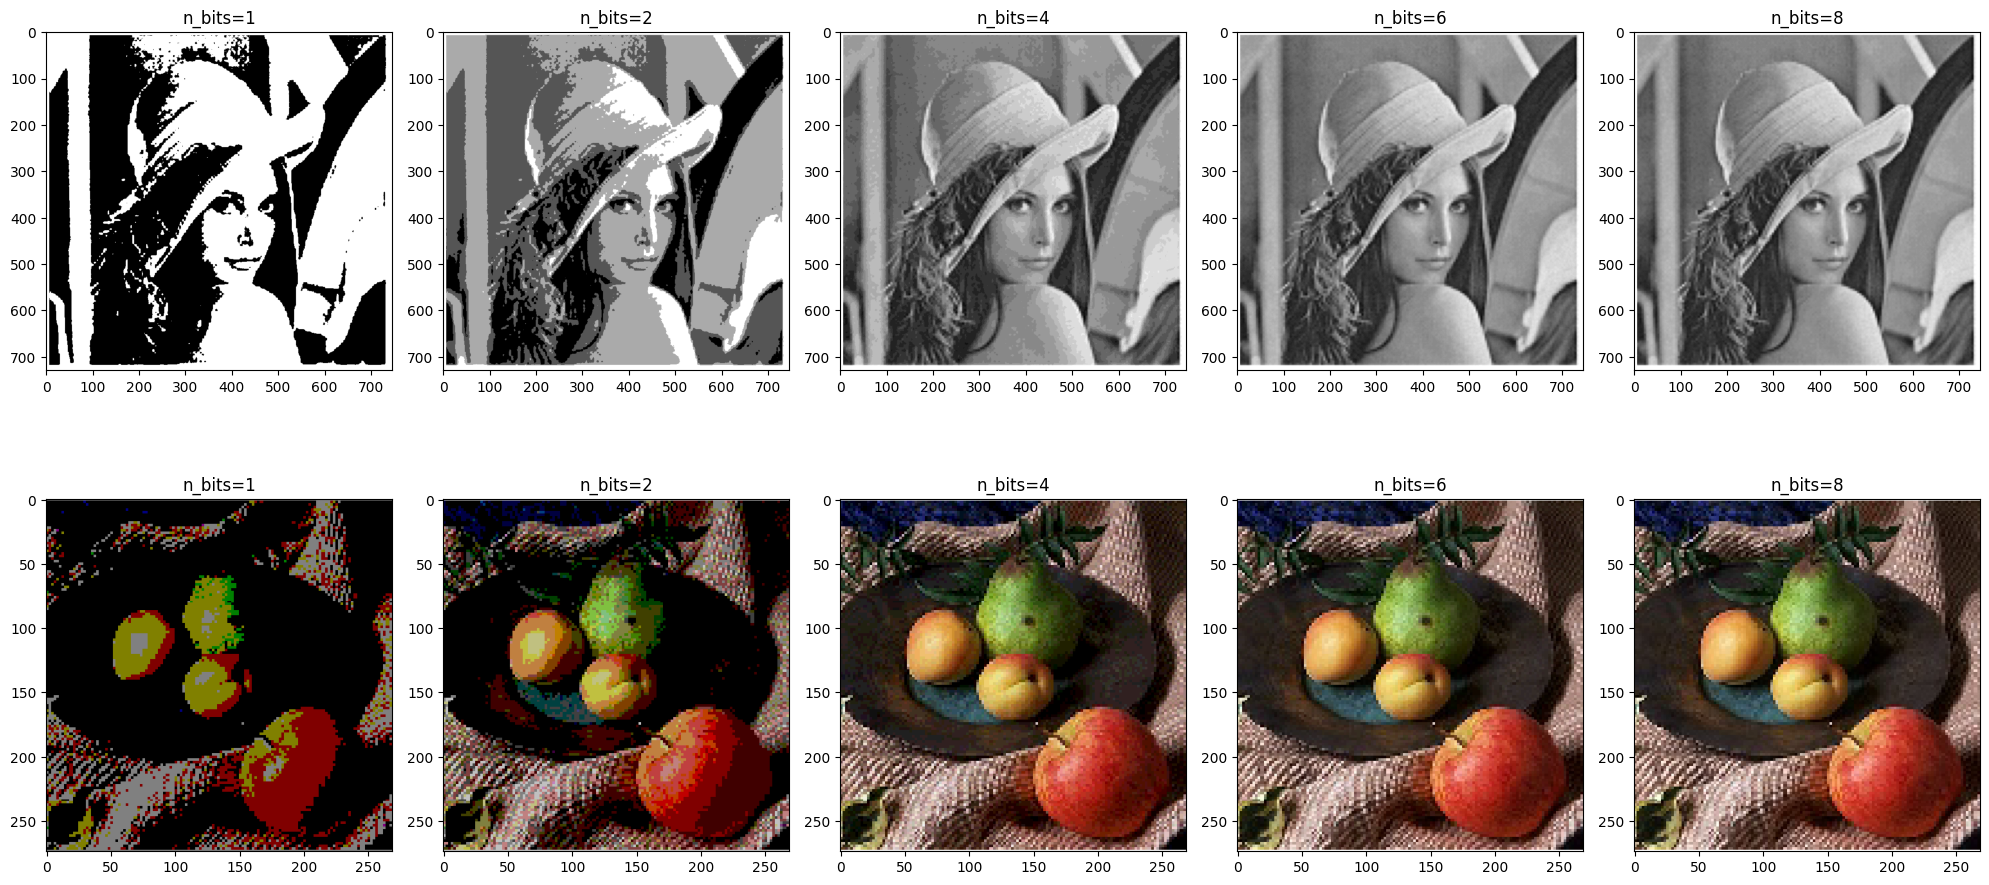

In [14]:
srcs = [cv2.imread("Lab/images/lenna.jpg"), cv2.imread("Lab/images/apple.png")]
n_bits_lst = [1, 2, 4, 6, 8]
fig, axes = plt.subplots(nrows=len(srcs), ncols=len(n_bits_lst), figsize=(20,10))
for i, n_bits in enumerate(n_bits_lst):
    n_levels = 2**n_bits
    intv = 256 // n_levels  # Use // for integer division
    print(n_levels, intv)
    for j, src in enumerate(srcs):
        src_quant = ( (src // intv) * intv ).astype(np.uint8)  # Ensure uint8 conversion
        if j == 0:
            axes[j, i].imshow(src_quant[...,0], cmap='gray')
        else:
            axes[j, i].imshow(cv2.cvtColor(src_quant, cv2.COLOR_BGR2RGB))  # Convert to RGB
        axes[j, i].set_title(f"n_bits={n_bits}")

plt.tight_layout()
plt.show()

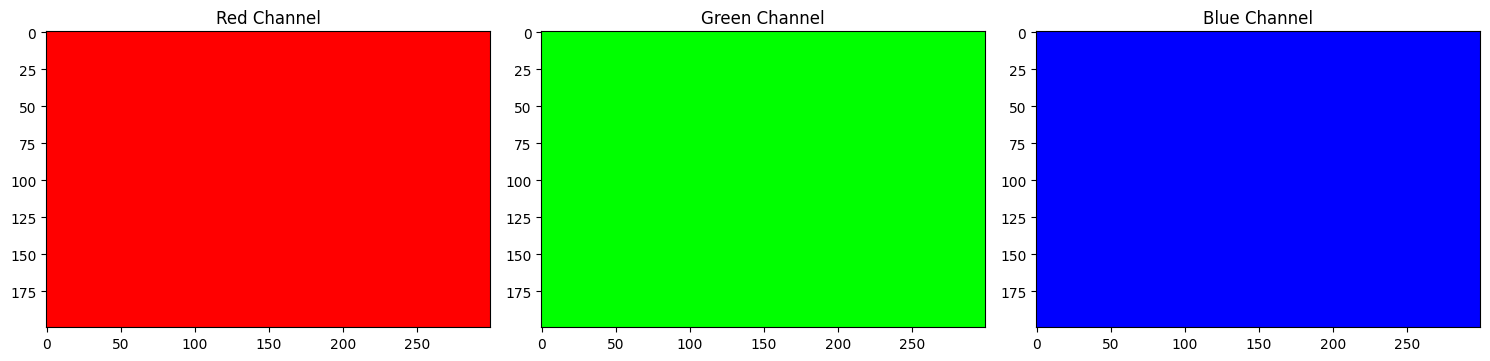

In [1]:
import numpy as np
import matplotlib.pyplot as plt

src_R = np.zeros((200, 300, 3), dtype=np.uint8)
src_R[:, :, 0] = 255  # Red channel

src_G = np.zeros((200, 300, 3), dtype=np.uint8)
src_G[:, : , 1] = 255  # Green channel

src_B = np.zeros((200, 300, 3), dtype=np.uint8)
src_B[:, :, 2] = 255  # Blue channel

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
axes[0].imshow(src_R)
axes[0].set_title("Red Channel")
axes[1].imshow(src_G)
axes[1].set_title("Green Channel")
axes[2].imshow(src_B)
axes[2].set_title("Blue Channel")
plt.tight_layout()
plt.show()


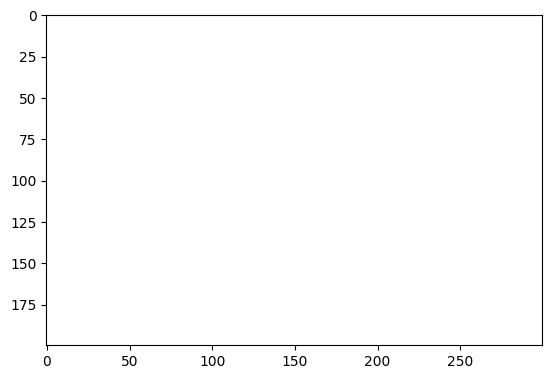

In [4]:
dst = src_R + src_G + src_B
plt.imshow(dst)

CMY


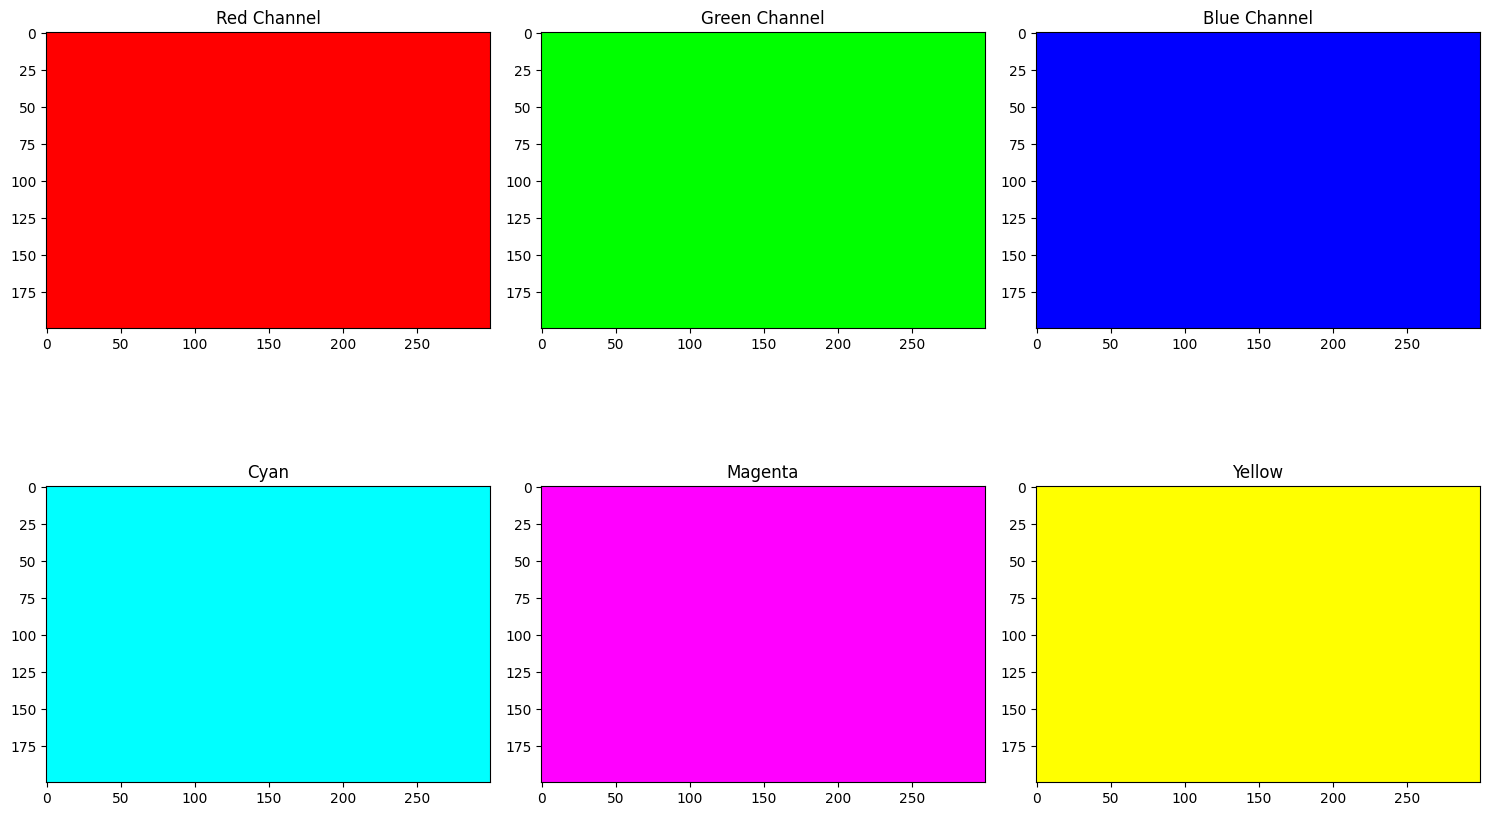

In [5]:
import numpy as np
import matplotlib.pyplot as plt

src_R = np.zeros((200, 300, 3), dtype=np.uint8)
src_R[..., 0] = 255  # Red channel

src_G = np.zeros((200, 300, 3), dtype=np.uint8)
src_G[..., 1] = 255  # Green channel

src_B = np.zeros((200, 300, 3), dtype=np.uint8)
src_B[..., 2] = 255  # Blue channel

"Cyan"
src_c = np.full((200, 300, 3), 255, dtype=np.uint8)
src_c[:, :, 0] = 0

"Magenta"
src_m = np.full((200, 300, 3), 255, dtype=np.uint8)
src_m[:, :, 1] = 0

"Yellow"
src_y = np.full((200, 300, 3), 255, dtype=np.uint8)
src_y[:, :, 2] = 0

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,10))
axes[0, 0].imshow(src_R)
axes[0, 0].set_title("Red Channel")
axes[0, 1].imshow(src_G)
axes[0, 1].set_title("Green Channel")
axes[0, 2].imshow(src_B)
axes[0, 2].set_title("Blue Channel")
axes[1, 0].imshow(src_c)
axes[1, 0].set_title("Cyan")
axes[1, 1].imshow(src_m)
axes[1, 1].set_title("Magenta")
axes[1, 2].imshow(src_y)
axes[1, 2].set_title("Yellow")
plt.tight_layout()
plt.show()

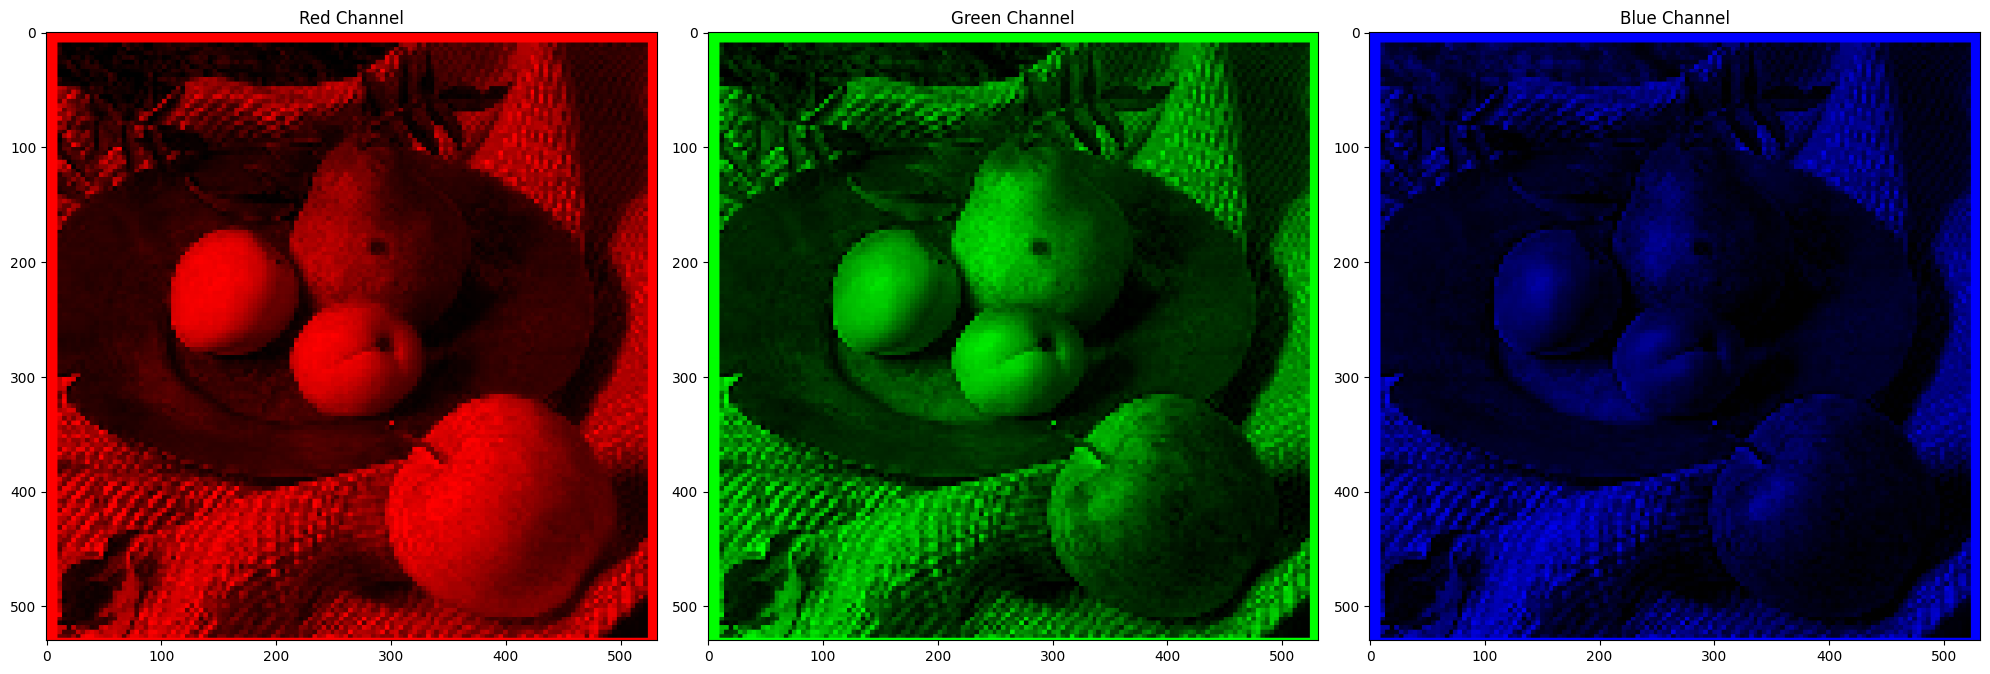

In [ ]:
src = plt.imread("images/apple2.jpg")
src = src[:, :, 0:3]

src_R = np.zeros_like(src)
src_G = np.zeros_like(src)
src_B = np.zeros_like(src)
src_R[:,:,0] = src[:,:,0]
src_G[:,:,1] = src[:,:,1]
src_B[:,:,2] = src[:,:,2]


plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(src_R)
plt.title("Red Channel")
plt.subplot(1, 3, 2)
plt.imshow(src_G)
plt.title("Green Channel")
plt.subplot(1, 3, 3)
plt.imshow(src_B)
plt.title("Blue Channel")
plt.tight_layout()
plt.show()

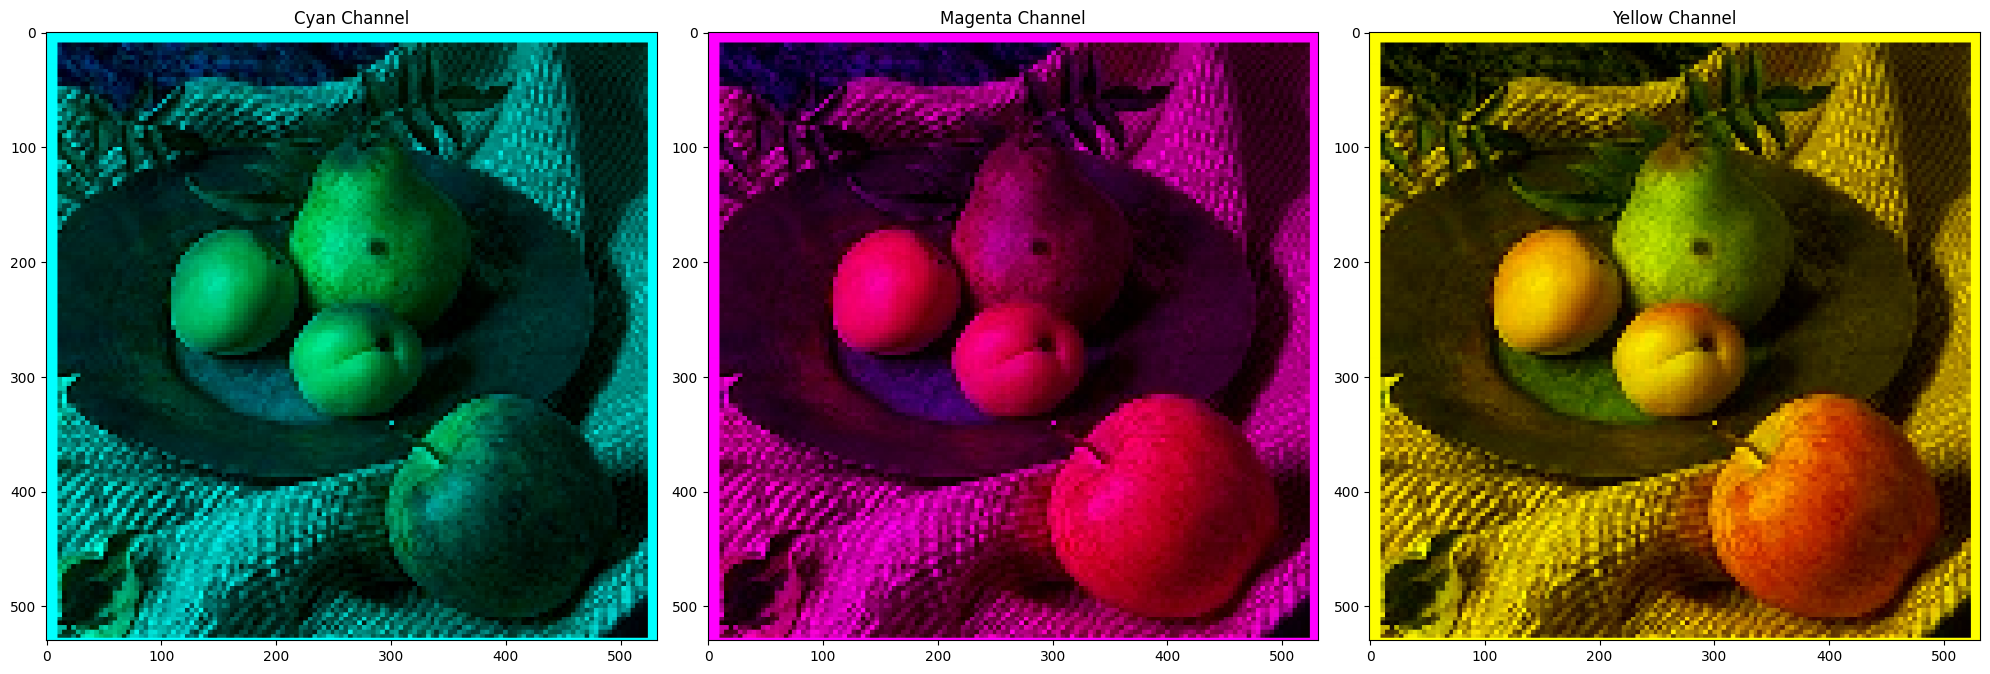

In [9]:
src = plt.imread("images/apple2.jpg")
src = src[:, :, 0:3]

src_C = np.zeros_like(src)
src_M = np.zeros_like(src)
src_Y = np.zeros_like(src)
src_C[:,:,1:3] = src[:,:,1:3]
src_M[:,:,0:3:2] = src[:,:,0:3:2]
src_Y[:,:,0:2] = src[:,:,0:2]


plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(src_C)
plt.title("Cyan Channel")
plt.subplot(1, 3, 2)
plt.imshow(src_M)
plt.title("Magenta Channel")
plt.subplot(1, 3, 3)
plt.imshow(src_Y)
plt.title("Yellow Channel")
plt.tight_layout()
plt.show()